# Solving a regression problem using decision trees and random forests

In this lab we'll use tow different kinds of machine learning methods to solve a regression problem. The considered problem is one for which the data set can be loaded directly using scikit-learn.

More about

*   Decision Trees - [scikit-learn](https://scikit-learn.org/stable/modules/tree.html)
*   Random Forests - [scikit-learn](https://scikit-learn.org/stable/modules/ensemble.html#random-forests-and-other-randomized-tree-ensembles)

## 1 - Some metrics used with regression problems

Suppose we want to evaluate these metrics on a set (assuming a single output value)
$$\left(Y_j,Y^t_j\right)_{j \in \{1,\dots,n\}}$$ where $Y_j$ is the predicted output and $Y^t_j$ the original target output.

*   **Max Error** defined as $\mbox{ME}=\max_{j \in \{1,\dots,n\}} |Y_j-Y^t_j|$. Unfortunately usually it is does correctly reflect the performance.
*   **Mean Absolute Error** defined as $\mbox{MAE}=\frac{1}{n} \sum_{j \in \{1,\dots,n\}} |Y_j-Y^t_j|$
*   **Mean Squared Error** defined as $\mbox{MSE}=\frac{1}{n} \sum_{j \in \{1,\dots,n\}} (Y_j-Y^t_j)^2$
*   **$R^2$ score** is defined by $$R^2 = 1 - \frac{\sum_{j \in \{1,\dots,n\}}\left(Y_j-Y^t_j\right)^2}{\sum_{j \in \{1,\dots,n\}} \left(\bar{Y}-Y^t_j\right)^2}$$ where $\bar{Y}$ represents the mean of $Y_j$.
$R^2$ is between $0$ and $1$ and the closer it is to $1$, the best the classifier.



## 2 - Decision Trees learning explained: [Machine Learning / David Gerbing](https://web.pdx.edu/~gerbing/Books/ML/) and [Wikipedia](https://en.wikipedia.org/wiki/Decision_tree_learning)

## 3 - Random Forests explained : [Wikipedia](https://en.wikipedia.org/wiki/Random_forest)


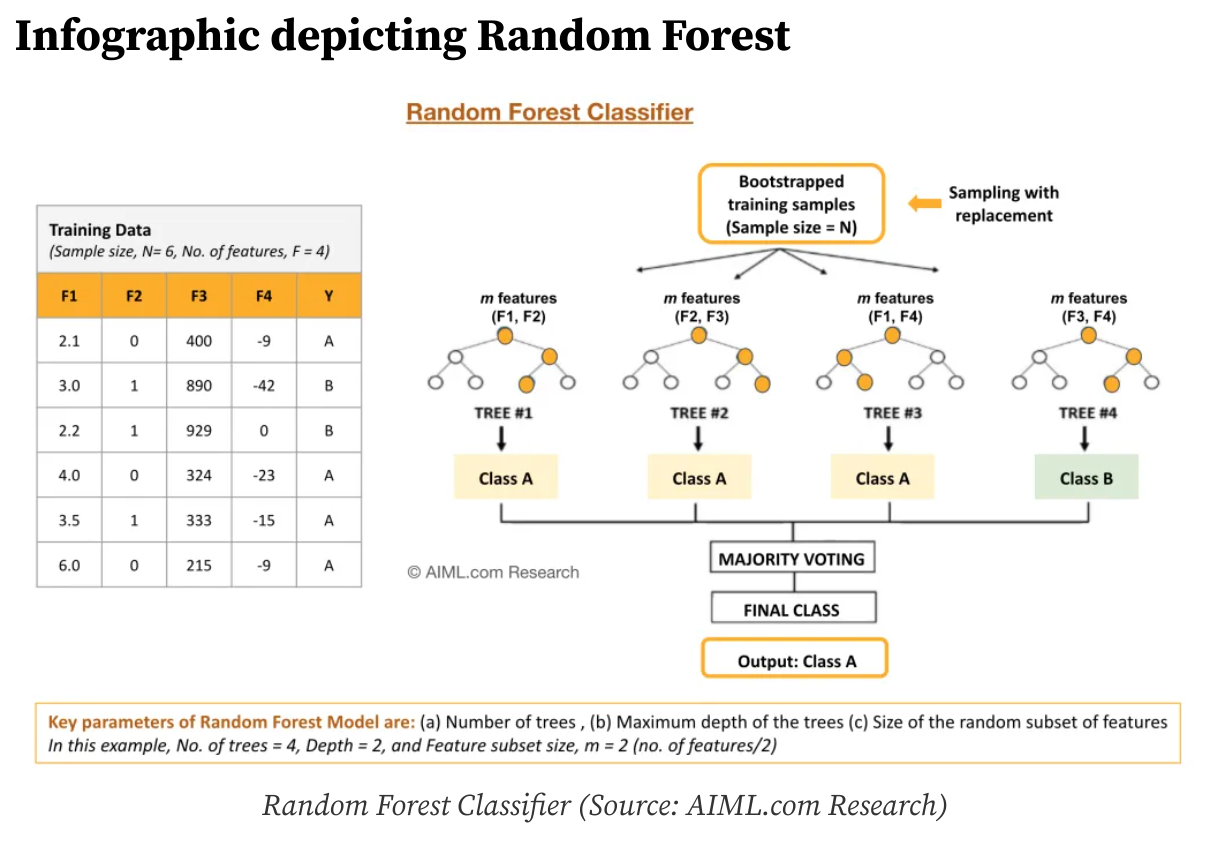

# What are you going to do?

In this Colab notebook you have to complete following steps:
1.   Load the boston data set. What kind of data does it contain?
2.   Train a regression Decision Tree to predict real estate value.
3.   Train several decision trees using increasing max_depth values.
4.   Train Random Forests by varying the max_depth value as done previously for decision tree.
5.   Show that scikit-learn simply averages the trees predictions of the forest.
6.   Rather than averaging the predictions of the different trees, uses Linear Regression to give them different weights
7.


## 1 - Load the boston data set

In [4]:
from sklearn.datasets import load_boston
data = load_boston()
X, y = data.data, data.target

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [5]:
# 1 - To find how to load the data set try to load the boston data set from scikit-learn
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")

# 2 - Define X and y
X = boston.data.astype(float)
y = boston.target.astype(float)

The inputs / features names are as follows:

* CRIM - per capita crime rate by town

* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

* INDUS - proportion of non-retail business acres per town.

* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

* NOX - nitric oxides concentration (parts per 10 million)

* RM - average number of rooms per dwelling

* AGE - proportion of owner-occupied units built prior to 1940

* DIS - weighted distances to five Boston employment centres

* RAD - index of accessibility to radial highways

* TAX - full-value property-tax rate per $10,000

* PTRATIO - pupil-teacher ratio by town

* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

* LSTAT - % lower status of the population

* MEDV - Median value of owner-occupied homes in $1000's

In [6]:
# 3 - Display the inputs and output of the first data sample
print("Inputs:\n", X.iloc[0])
print("Output:", y.iloc[0])

Inputs:
 CRIM         0.00632
ZN          18.00000
INDUS        2.31000
CHAS         0.00000
NOX          0.53800
RM           6.57500
AGE         65.20000
DIS          4.09000
RAD          1.00000
TAX        296.00000
PTRATIO     15.30000
B          396.90000
LSTAT        4.98000
Name: 0, dtype: float64
Output: 24.0


In [7]:
# 4 -Split data set into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## 2 - Train a regression decision tree to predict real estate value, plot the tree, and the importance of each of inputs / features. Evaluate the tree with $\mbox{MSE}$ and $R^2$ on both train and test sets.
Use scikit-learn's tree API to evaluate with $\mbox{MSE}$ and $R^2$.

In [8]:
# 1 - Import MSE and R^2 from scikit-learn's tree API
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
# 2 - Train regressor decision tree using max_depth value of 2
from sklearn.tree import DecisionTreeRegressor
rdt = DecisionTreeRegressor(max_depth=2)
rdt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2)

In [11]:
# 3 - Predict values for the test set
y_pred = rdt.predict(X_test)

In [12]:
# 4 - Print MSE and R^2 errors / metrics for test set
print('MSE : {}'.format(mean_squared_error(y_test, y_pred)))
print('R2 : {}'.format(r2_score(y_test, y_pred)))

MSE : 29.984994174650925
R2 : 0.6145177682628146


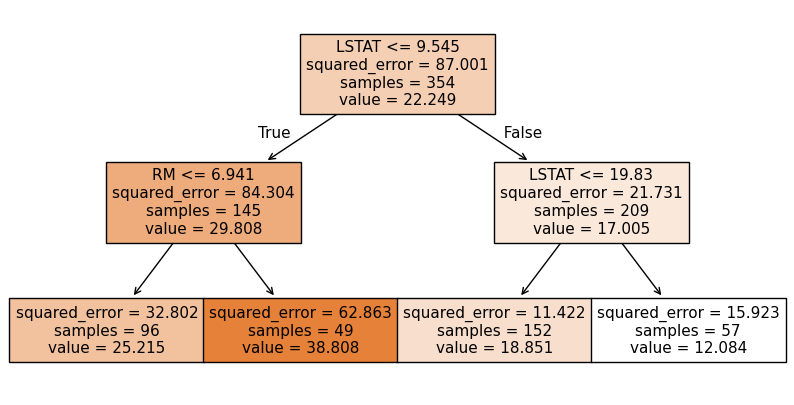

In [13]:
# 5 - Use plot_tree from tree API to display the rules of the decision tree
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,5))
plot_tree(rdt, feature_names=X.columns, filled=True)
plt.show()

Which inputs / features are the most important?

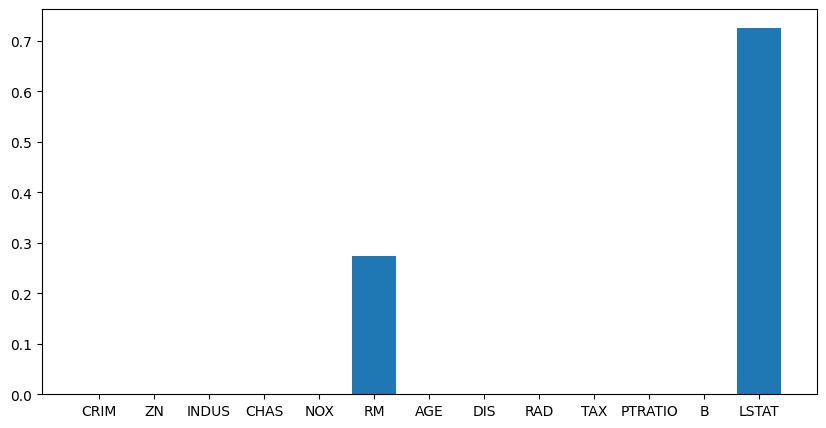

In [14]:
# 6 - Use features_importances values of the decision tree to plot an histogram showing the inputs / features importance
plt.figure(figsize=(10,5))
plt.bar(X.columns, rdt.feature_importances_)
plt.show()

## 3 - Train several decision trees using increasing max_depth values: 50 trees using max_depth values from 1 to 50. Save $\mbox{MSE}$ and $R^2$ values evaluated on train and test sets for each DT. Once the 50 DTs have been trained, plot the curves of the two metrics according to the value of the decision tree maximum depth.

In [15]:
# 1 - Define some useful variables
max_depth_ls = [i for i in range(1,50)]
mse_train = []
mse_test = []
r2_train = []
r2_test = []

In [16]:
# 2 - Train the 50 DTs and save their respective MSE and R^2 values
for m in max_depth_ls :
    dt = DecisionTreeRegressor(max_depth=m)
    dt.fit(X_train, y_train)

    mse_train.append(mean_squared_error(y_train, dt.predict(X_train)))
    mse_test.append(mean_squared_error(y_test, dt.predict(X_test)))

    r2_train.append(r2_score(y_train, dt.predict(X_train)))
    r2_test.append(r2_score(y_test, dt.predict(X_test)))

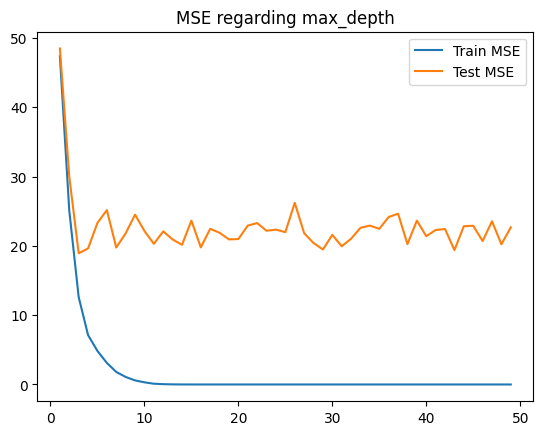

In [17]:
# 3 - Plot the MSE train and test curves according to max_depth
plt.figure()
plt.plot(max_depth_ls, mse_train, label='Train MSE')
plt.plot(max_depth_ls, mse_test, label='Test MSE')
plt.title('MSE regarding max_depth')
plt.legend()
plt.show()

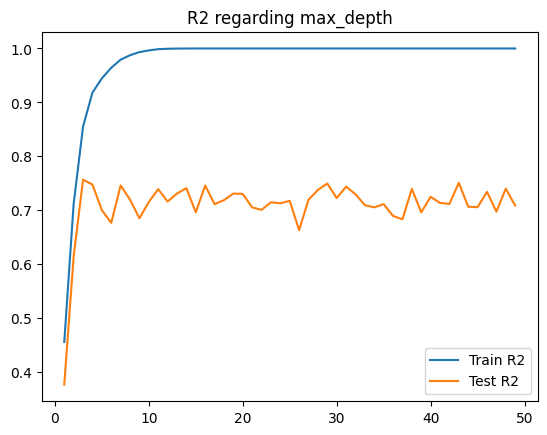

In [18]:
# 4 - Plot the R^2 train and test curves according to max depth
plt.figure()
plt.plot(max_depth_ls, r2_train, label='Train R2')
plt.plot(max_depth_ls, r2_test, label='Test R2')
plt.title('R2 regarding max_depth')
plt.legend()
plt.show()

What can you observe?

## 4 - Now switch to random forests and continue to vary the max_depth value as done previously for decision tree. Use 100 and 0 as the n_estimators and random_state values, respectively.

In [19]:
# 1 - Train a RF using 20 as max_depth value
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, random_state=0)

In [20]:
# 2 - Print MSE and R^2 errors / metrics for test set
print('MSE :', mean_squared_error(y_test, rf.predict(X_test)))
print('R2 :', r2_score(y_test, rf.predict(X_test)))

MSE : 10.369878414473689
R2 : 0.8666865215723818


In [21]:
# 3 - Train the 50 RFs and save their respective MSE and R^2 values
max_depth_ls = [i for i in range(1,50)]
mse_train = []
mse_test = []
r2_train = []
r2_test = []


for m in max_depth_ls :
    rf_m = RandomForestRegressor(n_estimators=100, max_depth=m, random_state=0)
    rf_m.fit(X_train, y_train)

    mse_train.append(mean_squared_error(y_train, rf_m.predict(X_train)))
    mse_test.append(mean_squared_error(y_test, rf_m.predict(X_test)))

    r2_train.append(r2_score(y_train, rf_m.predict(X_train)))
    r2_test.append(r2_score(y_test, rf_m.predict(X_test)))

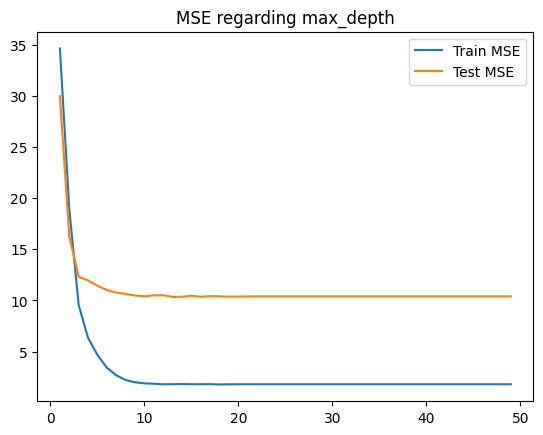

In [22]:
# 4 - Plot the MSE train and test curves according to max_depth
plt.figure()
plt.plot(max_depth_ls, mse_train, label='Train MSE')
plt.plot(max_depth_ls, mse_test, label='Test MSE')
plt.title('MSE regarding max_depth')
plt.legend()
plt.show()

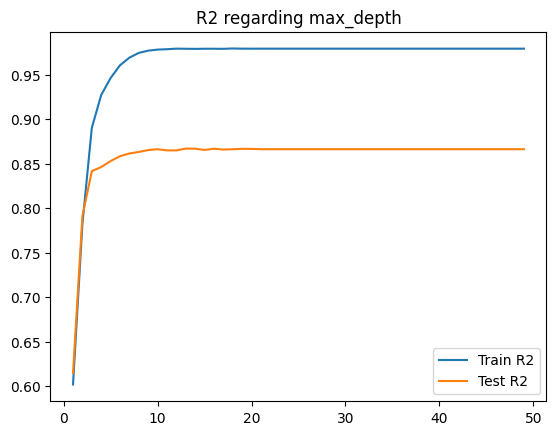

In [23]:
# 5 - Plot the R^2 train and test curves according to max depth
plt.figure()
plt.plot(max_depth_ls, r2_train, label='Train R2')
plt.plot(max_depth_ls, r2_test, label='Test R2')
plt.title('R2 regarding max_depth')
plt.legend()
plt.show()

What can you observe?

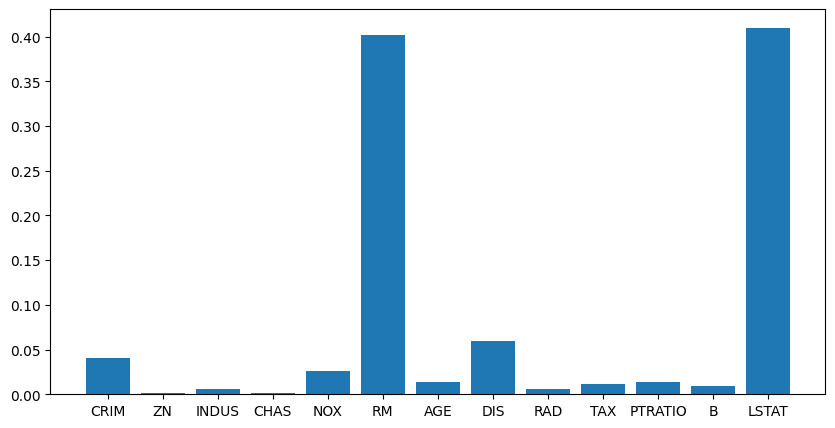

In [24]:
# 6 - Use features_importances values of the last random forest to plot an histogram showing the inputs / features importance
plt.figure(figsize=(10,5))
plt.bar(X.columns, rf_m.feature_importances_)
plt.show()

## 5 - Let us show that scikit-learn simply aggregates the trees predictions of the forest by computing their average value.

In [25]:
import numpy as np

# 1 - Train a random forest with same parameters as above
rf_agg = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=0)
rf_agg.fit(X_train, y_train)

# 2 - Get access to each tree of the forest using parameter estimators_ of the RF - see scikit-learn
trees = rf_agg.estimators_

# 3 - Compute the average value of the predictions given by the different trees and use it to compute R^2
X_test_arr = np.array(X_test)
tree_preds = np.array([tree.predict(X_test_arr) for tree in trees])
avg_preds = np.mean(tree_preds, axis=0)

print(r2_score(y_test, avg_preds))

0.8666865215723818


In [26]:
# 4 - Compute R^2 score using the predictions given by the Random Forest trained in step 1
print(r2_score(y_test, rf_agg.predict(X_test)))

0.8666865215723818


## 6 - Rather than averaging the predictions of the different trees, let us try to learn how use different weights for the trees using a Linear Regression

The idea is to find the set of weights $w_1,\dots,w_B$  such that : $$ Y= P_{RF}(X) = \sum_{i=1,\dots,B} P_{DT_i} f_i(X)$$
where
* $B$ is the number of trees,
* $P_{RF}$ are the Random Forest's predictions,
* $P_{DT_i}$ are the predictions given by Decision Tree $i$.

In [27]:
from sklearn.linear_model import LinearRegression

# 1 - Let us define a function that define the predictions given by the different DTs as the new features
def new_features(forest, X):
    X_arr = np.array(X)
    return np.array([tree.predict(X_arr) for tree in forest.estimators_]).T

In [28]:
# 2 - Define new train and test sets using the new_features / predictions of the RF for X_train and X_test , respectively
X_train2, X_test2 = new_features(rf_agg, X_train), new_features(rf_agg, X_test)

In [29]:
# 3 -  Train linear regression
lr = LinearRegression()
lr.fit(X_train2, y_train)

LinearRegression()

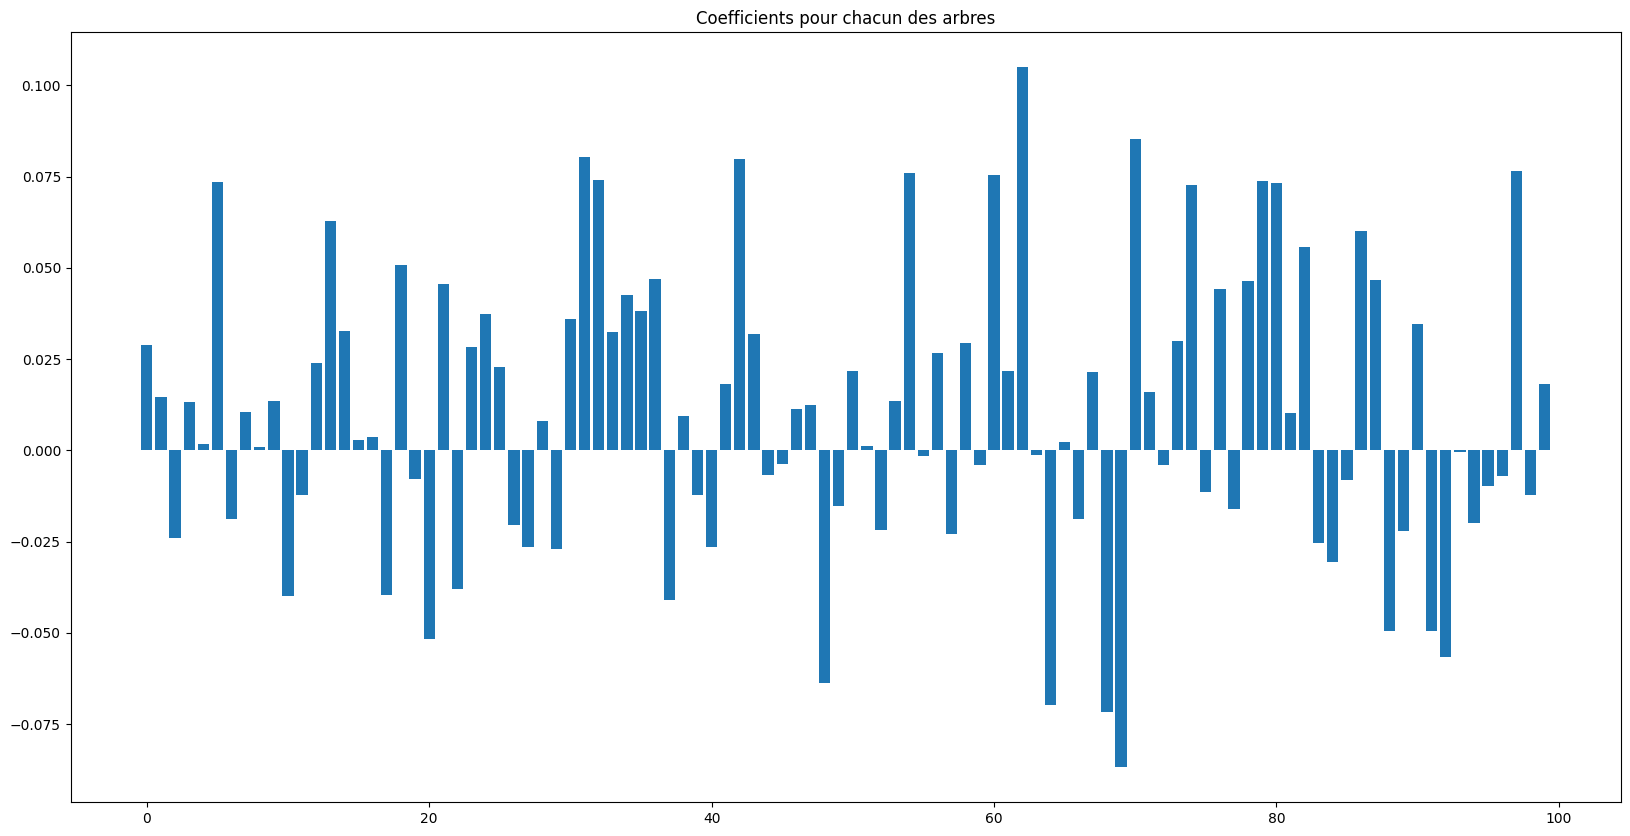

In [30]:
# 4 - Show the weights values / linear regression coefficients
plt.figure(figsize = (20,10))
plt.bar(range(len(lr.coef_)), lr.coef_)
plt.title('Coefficients pour chacun des arbres')
plt.show()

In [31]:
# 5 - Predict values for the new test set using linear regression
y_pred_lr = lr.predict(X_test2)

In [33]:
# 6 - Print MSE and R^2 errors / metrics for the new test set
print(mean_squared_error(y_test, y_pred_lr))
print(r2_score(y_test, y_pred_lr))

12.882989060622563
0.8343783778776623


## 7 - Try to replace Linear Regression with Lasso Regression